# 可视化数学与函数画图
## 计算需要描述、推理、优化和预测
- 描述结构:集合、图论
- 推理真假:梳理逻辑
- 处理数据:线性代数
- 训练模型:微积分与优化
- 面对不确定性：概率统计
- 分析效率：算法数学
## AI，CS，DS的区别：
- CS：怎么计算？
- DS：数据在说明什么？能带来什么价值？
- AI: 如何让机器像人一样思考？


## 一次函数
一次函数  $y=ax+b$  a是系数 b是起点和基准（基础量）Regression

线性回归中在排除x的影响后y的基准量

变化率：斜率a表示当x增加一个单位，y会相应的增加一个单位

倾斜方向：
    a>0 正
    a<0 负
    a=0 临界

！！！陡峭程度：（a的绝对值大小）--> y对x的敏感程度，越陡越敏感

## 二次函数
二次函数 $y = ax^2 + bx + c$

$c$ 截距

二次项系数 $a$
   - 决定了抛物线的开口方向，$a>0$向上微笑，小于$a<0$向下哭泣
   - 决定了抛物线的宽窄，a绝对值越大越窄，反之越宽
   $a$  代表了加速度和曲率

$b$不能单独决定位置 需要与$a$配合 $x=-a/b$


## 3D曲面 $z=x^2+y^2$ 抛物面：抛物线在三维空间的延申
  $x$ $y$ 是自变量 $z$ 是因变量
  $z$ 截取是圆
  $x$ $y$ 截取是抛物面
  斜着截？
  a，b 一正一负？

梯度下降算法 算法会计算当前位置山坡的“陡峭方向”
LR 学习率 步子的大小 步长 步长过大 跨过终点  模型无法收敛


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
print('工具加载成功')

工具加载成功


## 一次函数($y=ax+b$)

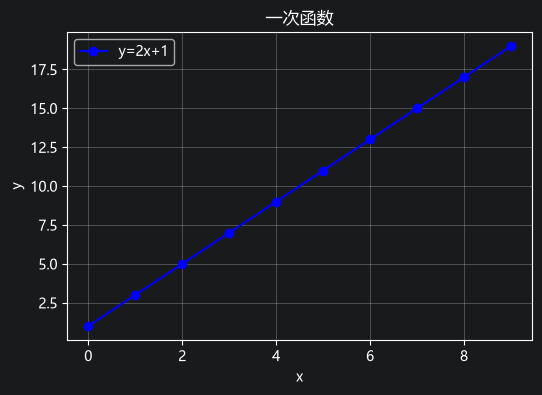

In [9]:
# 画y=2x+1
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = 2 * x + 1
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'b-o', label='y=2x+1')
plt.title("一次函数")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

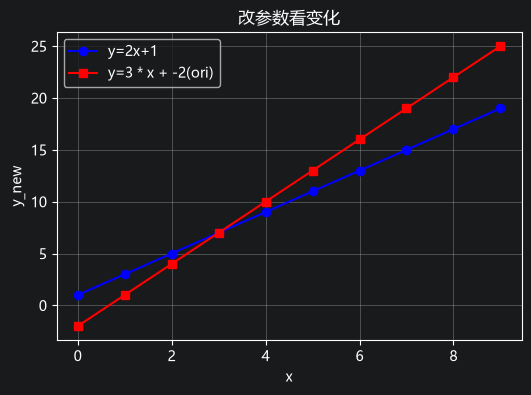

In [3]:
slope = 3
intercept = -2
y_new = slope * x + intercept

plt.figure(figsize=(6, 4))
plt.plot(x, y, 'b-o', label='y=2x+1')
plt.plot(x, y_new, 'r-s', label=f'y={slope} * x + {intercept}(ori)')
plt.title('改参数看变化')
plt.xlabel('x')
plt.ylabel('y')
plt.ylabel('y_new')
plt.legend()
plt.grid(True)
plt.show()

## 二次函数($y = ax^2 + bx + c$)

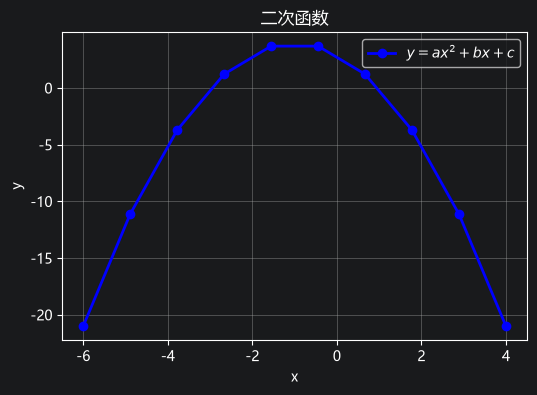

In [8]:
# y = a*x**2+b*x+c

a, b, c = -1, -2, 3

x = np.linspace(-6, 4, 10)
y = a * x ** 2 + b * x + c
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'b-o', label='$y = ax^2 + bx + c$', linewidth=2, )
plt.title("二次函数")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 二元二次函数($z=x^2+y^2$)

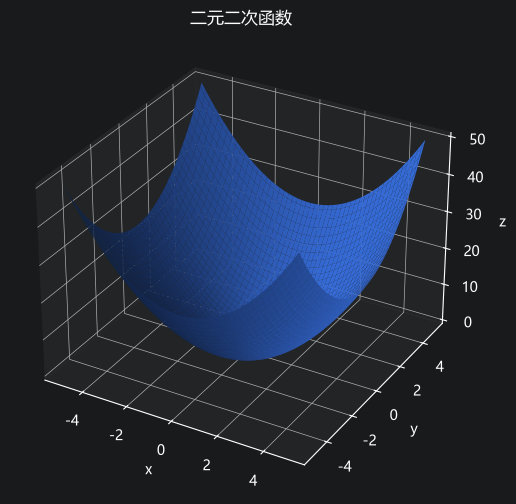

In [10]:
# 绘制 z=x^2+y^2

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)

Z = X ** 2 + Y ** 2
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z)
plt.title("二元二次函数")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

##  一次函数拟合房价

作业：用直线拟合数据预测房价
样本数据：面积(㎡)  ->  总价(万元)
    50  ->   235
    60  ->   285
    70  ->   330
    80  ->   375
    90  ->   420
   100  ->   465
   110  ->   510
   120  ->   555

拟合直线：房价 = 4.54 * 面积 + 10.83
即每增加 1 平方米，房价平均上涨约 4.54 万元
预测：85 平方米的房子 ≈ 396.9 万元
预测：135 平方米的房子 ≈ 624.0 万元


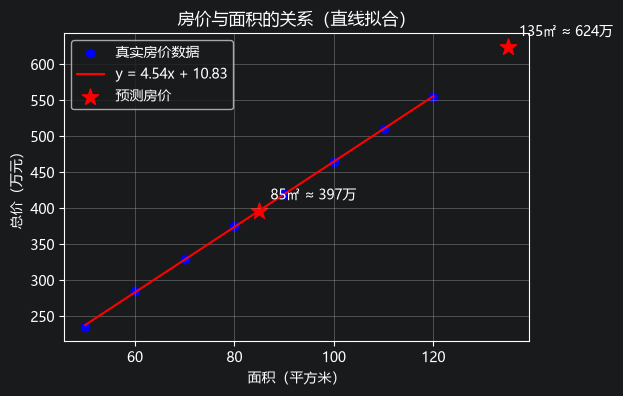

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============ 1. 收集数据 ============
# 房屋面积（平方米）
x = np.array([50, 60, 70, 80, 90, 100, 110, 120])
# 对应房屋总价（万元）
y = np.array([235, 285, 330, 375, 420, 465, 510, 555])

print("样本数据：面积(㎡)  ->  总价(万元)")
for i in range(len(x)):
    print(f"  {x[i]:>4}  ->  {y[i]:>4}")

# ============ 2. 最小二乘法拟合直线 ============
# 用 numpy 拟合一次函数 y = k * x + b
k, b = np.polyfit(x, y, 1)
print(f"\n拟合直线：房价 = {k:.2f} * 面积 + {b:.2f}")
print(f"即每增加 1 平方米，房价平均上涨约 {k:.2f} 万元")

# ============ 3. 用拟合直线预测房价 ============
x_new = np.array([85, 135])  # 想预测的面积
y_pred = k * x_new + b  # 预测的总价
for i in range(len(x_new)):
    print(f"预测：{x_new[i]} 平方米的房子 ≈ {y_pred[i]:.1f} 万元")

# ============ 4. 画图展示 ============
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='b', label='真实房价数据')  # 真实数据散点
plt.plot(x, k * x + b, 'r-', label=f'y = {k:.2f}x + {b:.2f}')  # 拟合直线
plt.scatter(x_new, y_pred, color='r', marker='*', s=150, label='预测房价')  # 预测点
# 给预测点标上数值
for i in range(len(x_new)):
    plt.annotate(f'{x_new[i]}㎡ ≈ {y_pred[i]:.0f}万',
                 (x_new[i], y_pred[i]),
                 textcoords="offset points", xytext=(8, 8))
plt.title('房价与面积的关系（直线拟合）')
plt.xlabel('面积（平方米）')
plt.ylabel('总价（万元）')
plt.legend()
plt.grid(True)
plt.show()
